In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [162]:
df = pd.read_csv('../Data/processed/Gurgaon_cleaned_final_1.csv')
df.head()

,property_type,sector,price,area,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,7.0,0.45,900.0,2,2,1,4.0,Relatively New,1066.350711,0,0,0,0,0,0,28
1,flat,5.0,0.50,650.0,2,2,1,1.0,Old Property,770.142180,0,0,0,0,0,1,37
2,flat,48.0,0.40,595.0,2,2,3,12.0,New Property,704.976303,0,0,0,0,0,0,36
3,flat,61.0,1.47,1200.0,2,2,2,2.0,Under Construction,1421.800948,1,0,0,0,0,0,76
4,flat,92.0,0.70,1345.0,2,2,3,5.0,Under Construction,1185.022026,1,0,0,0,0,0,0


In [163]:
df = pd.get_dummies(df, columns=['property_type','agePossession'], drop_first=True)

In [164]:
df.shape

(3853, 20)

In [165]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [166]:
df.luxury_score = df.luxury_score.apply(categorize_luxury)

In [167]:
df.drop(columns=['area'], inplace=True, errors='ignore')

In [168]:
df = pd.get_dummies(df, columns=['luxury_score'], drop_first=True)

In [169]:
X = df.drop(columns=['price'])
y = df['price']

<Axes: >

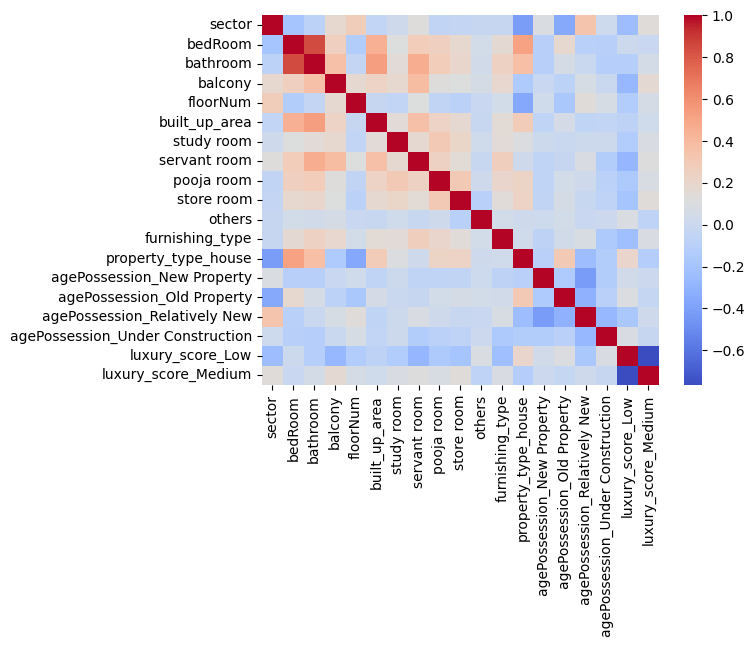

In [170]:
sns.heatmap(X.corr(),  cmap='coolwarm')

In [171]:
fi_df1 = df.corr()['price'].drop('price').to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.145414
1,bedRoom,0.510436
2,bathroom,0.597322
3,balcony,0.228798
4,floorNum,-0.073250
5,built_up_area,0.686357
6,study room,0.242169
7,servant room,0.397470
8,pooja room,0.317852
9,store room,0.300818


# Using Random Forest Technique

In [172]:
X.head()

,sector,bedRoom,bathroom,balcony,floorNum,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,property_type_house,agePossession_New Property,agePossession_Old Property,agePossession_Relatively New,agePossession_Under Construction,luxury_score_Low,luxury_score_Medium
0,7.0,2,2,1,4.0,1066.350711,0,0,0,0,0,0,False,False,False,True,False,True,False
1,5.0,2,2,1,1.0,770.142180,0,0,0,0,0,1,False,False,True,False,False,True,False
2,48.0,2,2,3,12.0,704.976303,0,0,0,0,0,0,False,True,False,False,False,True,False
3,61.0,2,2,2,2.0,1421.800948,1,0,0,0,0,0,False,False,False,False,True,False,True
4,92.0,2,2,3,5.0,1185.022026,1,0,0,0,0,0,False,False,False,False,True,True,False


In [173]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract features importancee

fi_df2 = pd.DataFrame({'feature': X.columns, 'RF_Importance': rf.feature_importances_}).sort_values(by='RF_Importance', ascending=False)
fi_df2


,feature,RF_Importance
5,built_up_area,0.604053
0,sector,0.121901
12,property_type_house,0.082685
2,bathroom,0.043853
4,floorNum,0.027395
7,servant room,0.027344
1,bedRoom,0.024529
11,furnishing_type,0.011098
3,balcony,0.007654
6,study room,0.007352


# Gradient boosting technique

In [174]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X, y)

# Extract features importancee

fi_df3 = pd.DataFrame({'feature': X.columns, 'gb_Importance': gb.feature_importances_}).sort_values(by='gb_Importance', ascending=False)
fi_df3

,feature,gb_Importance
5,built_up_area,0.642866
0,sector,0.121855
12,property_type_house,0.081576
2,bathroom,0.065102
1,bedRoom,0.027265
7,servant room,0.024113
4,floorNum,0.014206
9,store room,0.008011
18,luxury_score_Medium,0.003459
3,balcony,0.003180


# Permutaion Technique

In [175]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train, y_train)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test, y_test, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
5,built_up_area,0.616449
12,property_type_house,0.153767
0,sector,0.129636
2,bathroom,0.023060
7,servant room,0.017156
4,floorNum,0.013667
18,luxury_score_Medium,0.008200
1,bedRoom,0.005196
15,agePossession_Relatively New,0.004131
9,store room,0.003579


# Lasso

In [176]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
5,built_up_area,1.204106
2,bathroom,0.695063
12,property_type_house,0.660315
7,servant room,0.226310
9,store room,0.225701
6,study room,0.172695
11,furnishing_type,0.160159
8,pooja room,0.094869
16,agePossession_Under Construction,0.092806
3,balcony,0.067786


# Technique RFE

In [177]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X.shape[1], step=1)
selector_label = selector_label.fit(X, y)

# Get the selected features based on RFE
selected_features = X.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
5,built_up_area,0.600664
0,sector,0.117537
12,property_type_house,0.089672
2,bathroom,0.047457
7,servant room,0.029245
1,bedRoom,0.025705
4,floorNum,0.022803
11,furnishing_type,0.011010
3,balcony,0.007775
15,agePossession_Relatively New,0.006708


# Linear Regression Weights

In [178]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
5,built_up_area,1.204631
2,bathroom,0.761063
12,property_type_house,0.692895
9,store room,0.230131
7,servant room,0.227978
6,study room,0.175053
11,furnishing_type,0.172882
16,agePossession_Under Construction,0.110372
8,pooja room,0.101500
18,luxury_score_Medium,0.083770


# Shap

In [179]:
!pip install shap

In [180]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)


In [181]:
shap_values
fi_df8 = pd.DataFrame({
    'feature': X.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
5,built_up_area,1.179479
0,sector,0.400573
12,property_type_house,0.393483
2,bathroom,0.231726
7,servant room,0.122162
4,floorNum,0.065000
1,bedRoom,0.051535
11,furnishing_type,0.041492
3,balcony,0.039388
6,study room,0.017897


In [182]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')
final_fi_df

,corr_coeff,RF_Importance,gb_Importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.145414,0.121901,0.121855,0.129636,-0.111771,0.117537,-0.129511,0.400573
bedRoom,0.510436,0.024529,0.027265,0.005196,-0.269346,0.025705,-0.355780,0.051535
bathroom,0.597322,0.043853,0.065102,0.023060,0.695063,0.047457,0.761063,0.231726
balcony,0.228798,0.007654,0.003180,0.001388,0.067786,0.007775,0.081847,0.039388
floorNum,-0.073250,0.027395,0.014206,0.013667,0.052990,0.022803,0.067314,0.065000
built_up_area,0.686357,0.604053,0.642866,0.616449,1.204106,0.600664,1.204631,1.179479
study room,0.242169,0.007352,0.001695,0.000198,0.172695,0.006399,0.175053,0.017897
servant room,0.397470,0.027344,0.024113,0.017156,0.226310,0.029245,0.227978,0.122162
pooja room,0.317852,0.003853,0.000033,-0.001537,0.094869,0.004159,0.101500,0.006297


In [183]:
# Normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [184]:
final_fi_df[['gb_Importance', 'lasso_coeff', 'permutation_importance', 'rfe_score', 'reg_coeffs', 'SHAP_score','RF_Importance']].mean(axis = 1).sort_values(ascending=False)    

feature
built_up_area                       0.519551
property_type_house                 0.137070
bathroom                            0.099539
sector                              0.082176
servant room                        0.039796
store room                          0.023383
floorNum                            0.019778
furnishing_type                     0.019451
study room                          0.017847
balcony                             0.011285
pooja room                          0.009528
agePossession_Under Construction    0.009509
luxury_score_Medium                 0.009314
agePossession_New Property          0.006448
luxury_score_Low                    0.004220
agePossession_Relatively New        0.004080
agePossession_Old Property          0.000462
others                             -0.001834
bedRoom                            -0.011603
dtype: float64

# With all columns, we can see that the top features are 'built_up_area', 'property_type_house', 'bathroom','sector', and 'agePossession'. 
# These features have the highest average importance across all methods, indicating that they are likely to be the most influential in predicting house prices in Gurgaon.

In [185]:
# with all columns
from sklearn.model_selection import cross_val_score
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Cross-validated R^2 scores:", scores)
print("scores mean:", scores.mean())

Cross-validated R^2 scores: [0.74543497 0.77607052 0.83696979 0.85538849 0.64254664]
scores mean: 0.7712820788089793


In [186]:
# with dropped columns like others, furnishing type and bedroom.
rf_dropped = RandomForestRegressor(n_estimators=100, random_state=42)
X_dropped = X.drop(columns=['others'], errors='ignore')
scores_dropped = cross_val_score(rf_dropped, X_dropped, y, cv=5, scoring='r2')
print("Cross-validated R^2 scores (dropped columns):", scores_dropped)
print("Dropped columns R^2 scores mean:", scores_dropped.mean())

Cross-validated R^2 scores (dropped columns): [0.74643899 0.77751135 0.83522803 0.85907175 0.64130189]
Dropped columns R^2 scores mean: 0.7719104003877884


In [187]:
# Check if the encoding order makes sense
df.groupby('furnishing_type')['price'].mean()

furnishing_type
0    1.912002
1    3.218333
2    3.657236
Name: price, dtype: float64

In [188]:
print(df[['bedRoom', 'built_up_area']].corr())

                bedRoom  built_up_area
bedRoom        1.000000       0.451625
built_up_area  0.451625       1.000000


In [189]:
print(df[['bedRoom', 'bathroom']].corr())

           bedRoom  bathroom
bedRoom   1.000000  0.844101
bathroom  0.844101  1.000000


In [191]:
# Exporting post feature selection dataset.
df.to_csv("../Data/processed/post_feature_selection.csv", index=False)
